<a href="https://colab.research.google.com/github/omarmohab78/car-price-predictation/blob/main/car_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor as DTR
from sklearn.tree import DecisionTreeRegressor

In [2]:
!git clone https://github.com/alexeygrigorev/mlbookcamp-code

Cloning into 'mlbookcamp-code'...
remote: Enumerating objects: 4489, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 4489 (delta 45), reused 33 (delta 33), pack-reused 4434 (from 1)
Receiving objects: 100% (4489/4489), 9.03 MiB | 11.21 MiB/s, done.
Resolving deltas: 100% (2720/2720), done.


In [3]:
dataset = pd.read_csv('/content/mlbookcamp-code/chapter-02-car-price/data.csv')

In [4]:
dataset.head(3)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350


In [5]:
dataset.shape

(11914, 16)

In [6]:
#length
len(dataset.columns)

16

In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

Some cleaning


In [8]:
dataset.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='object')

In [9]:
dataset.columns = dataset.columns.str.upper().str.replace('_','')

In [10]:
dataset.columns

Index(['MAKE', 'MODEL', 'YEAR', 'ENGINE FUEL TYPE', 'ENGINE HP',
       'ENGINE CYLINDERS', 'TRANSMISSION TYPE', 'DRIVENWHEELS',
       'NUMBER OF DOORS', 'MARKET CATEGORY', 'VEHICLE SIZE', 'VEHICLE STYLE',
       'HIGHWAY MPG', 'CITY MPG', 'POPULARITY', 'MSRP'],
      dtype='object')

In [11]:
dataset.rename(columns={'MSRP':'PRICE'},inplace=True)

In [12]:
dataset.columns

Index(['MAKE', 'MODEL', 'YEAR', 'ENGINE FUEL TYPE', 'ENGINE HP',
       'ENGINE CYLINDERS', 'TRANSMISSION TYPE', 'DRIVENWHEELS',
       'NUMBER OF DOORS', 'MARKET CATEGORY', 'VEHICLE SIZE', 'VEHICLE STYLE',
       'HIGHWAY MPG', 'CITY MPG', 'POPULARITY', 'PRICE'],
      dtype='object')

Analysis


In [13]:
pd.options.display.float_format = '{:.2f}'.format
dataset.describe()

,YEAR,ENGINE HP,ENGINE CYLINDERS,NUMBER OF DOORS,HIGHWAY MPG,CITY MPG,POPULARITY,PRICE
count,11914.00,11845.00,11884.00,11908.00,11914.00,11914.00,11914.00,11914.00
mean,2010.38,249.39,5.63,3.44,26.64,19.73,1554.91,40594.74
std,7.58,109.19,1.78,0.88,8.86,8.99,1441.86,60109.10
min,1990.00,55.00,0.00,2.00,12.00,7.00,2.00,2000.00
25%,2007.00,170.00,4.00,2.00,22.00,16.00,549.00,21000.00
50%,2015.00,227.00,6.00,4.00,26.00,18.00,1385.00,29995.00
75%,2016.00,300.00,6.00,4.00,30.00,22.00,2009.00,42231.25
max,2017.00,1001.00,16.00,4.00,354.00,137.00,5657.00,2065902.00


In [14]:
dataset.describe(include='object')

,MAKE,MODEL,ENGINE FUEL TYPE,TRANSMISSION TYPE,DRIVENWHEELS,MARKET CATEGORY,VEHICLE SIZE,VEHICLE STYLE
count,11914,11914,11911,11914,11914,8172,11914,11914
unique,48,915,10,5,4,71,3,16
top,Chevrolet,Silverado 1500,regular unleaded,AUTOMATIC,front wheel drive,Crossover,Compact,Sedan
freq,1123,156,7172,8266,4787,1110,4764,3048


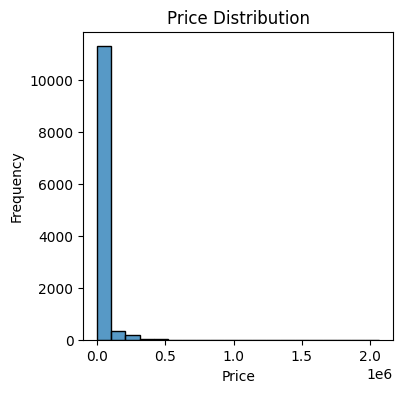

In [15]:
plt.figure(figsize=(4,4))

# Using brackets ['Price'] is safer and avoids the AttributeError
sns.histplot(dataset.PRICE, bins=20)

plt.ylabel('Frequency')
plt.xlabel('Price')
plt.title('Price Distribution')
plt.show()

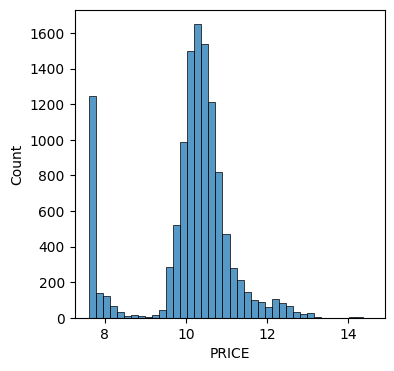

In [16]:
dataset['PRICE'] = np.log1p(dataset.PRICE)
plt.figure(figsize=(4, 4))
sns.histplot(dataset.PRICE, bins=40)
plt.show()

Remove duplicate rows


In [17]:
dataset.shape

(11914, 16)

In [18]:
dataset =dataset[dataset.duplicated()]
dataset.shape

(715, 16)

In [19]:
for col in dataset.columns:
  print(col,":", dataset[col].nunique() )
  print(dataset[col].value_counts().nlargest(5))
  print('\n' + "*" * 20 + '\n')

MAKE : 32
MAKE
Volkswagen    241
Dodge          97
Ford           56
Hyundai        44
Chevrolet      40
Name: count, dtype: int64

********************

MODEL : 135
MODEL
Beetle Convertible    37
GTI                   36
Beetle                29
RAM 150               28
Jetta GLI             22
Name: count, dtype: int64

********************

YEAR : 23
YEAR
2015    105
2016     84
1992     50
1991     49
1993     49
Name: count, dtype: int64

********************

ENGINE FUEL TYPE : 6
ENGINE FUEL TYPE
regular unleaded                  514
premium unleaded (recommended)    131
premium unleaded (required)        53
flex-fuel (unleaded/E85)           12
diesel                              4
Name: count, dtype: int64

********************

ENGINE HP : 86
ENGINE HP
170.00    90
200.00    78
210.00    77
150.00    46
165.00    24
Name: count, dtype: int64

********************

ENGINE CYLINDERS : 6
ENGINE CYLINDERS
4.00     390
6.00     198
8.00      66
5.00      56
10.00      3
Name: count

Missing values

In [20]:
dataset = dataset.drop(columns='MARKET CATEGORY',axis=1)

In [21]:
print(dataset.isnull().sum())

MAKE                 0
MODEL                0
YEAR                 0
ENGINE FUEL TYPE     0
ENGINE HP            0
ENGINE CYLINDERS     0
TRANSMISSION TYPE    0
DRIVENWHEELS         0
NUMBER OF DOORS      0
VEHICLE SIZE         0
VEHICLE STYLE        0
HIGHWAY MPG          0
CITY MPG             0
POPULARITY           0
PRICE                0
dtype: int64


Encoding by get_dummies

In [22]:
dataset = pd.get_dummies(dataset, columns=['MAKE','MODEL','ENGINE FUEL TYPE','TRANSMISSION TYPE','DRIVENWHEELS','VEHICLE STYLE'])

In [23]:
dataset.head()

,YEAR,ENGINE HP,ENGINE CYLINDERS,NUMBER OF DOORS,VEHICLE SIZE,HIGHWAY MPG,CITY MPG,POPULARITY,PRICE,MAKE_Acura,...,VEHICLE STYLE_Convertible,VEHICLE STYLE_Convertible SUV,VEHICLE STYLE_Coupe,VEHICLE STYLE_Crew Cab Pickup,VEHICLE STYLE_Extended Cab Pickup,VEHICLE STYLE_Passenger Minivan,VEHICLE STYLE_Passenger Van,VEHICLE STYLE_Regular Cab Pickup,VEHICLE STYLE_Sedan,VEHICLE STYLE_Wagon
14,2013,230.00,6.00,2.00,Compact,28,19,3916,10.36,False,...,False,False,True,False,False,False,False,False,False,False
18,1992,172.00,6.00,4.00,Midsize,24,17,3105,7.60,False,...,False,False,False,False,False,False,False,False,True,False
20,1992,172.00,6.00,4.00,Midsize,24,17,3105,7.60,False,...,False,False,False,False,False,False,False,False,True,False
24,1993,172.00,6.00,4.00,Midsize,24,17,3105,7.60,False,...,False,False,False,False,False,False,False,False,True,False
25,1993,172.00,6.00,4.00,Midsize,24,17,3105,7.60,False,...,False,False,False,False,False,False,False,False,True,False


In [24]:
dataset['VEHICLE SIZE'] = dataset['VEHICLE SIZE'].replace({'Compact': 0, 'Midsize': 1, 'Large': 2})


/tmp/ipykernel_19319/1974589763.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset['VEHICLE SIZE'] = dataset['VEHICLE SIZE'].replace({'Compact': 0, 'Midsize': 1, 'Large': 2})


In [25]:
dataset.head()

,YEAR,ENGINE HP,ENGINE CYLINDERS,NUMBER OF DOORS,VEHICLE SIZE,HIGHWAY MPG,CITY MPG,POPULARITY,PRICE,MAKE_Acura,...,VEHICLE STYLE_Convertible,VEHICLE STYLE_Convertible SUV,VEHICLE STYLE_Coupe,VEHICLE STYLE_Crew Cab Pickup,VEHICLE STYLE_Extended Cab Pickup,VEHICLE STYLE_Passenger Minivan,VEHICLE STYLE_Passenger Van,VEHICLE STYLE_Regular Cab Pickup,VEHICLE STYLE_Sedan,VEHICLE STYLE_Wagon
14,2013,230.00,6.00,2.00,0,28,19,3916,10.36,False,...,False,False,True,False,False,False,False,False,False,False
18,1992,172.00,6.00,4.00,1,24,17,3105,7.60,False,...,False,False,False,False,False,False,False,False,True,False
20,1992,172.00,6.00,4.00,1,24,17,3105,7.60,False,...,False,False,False,False,False,False,False,False,True,False
24,1993,172.00,6.00,4.00,1,24,17,3105,7.60,False,...,False,False,False,False,False,False,False,False,True,False
25,1993,172.00,6.00,4.00,1,24,17,3105,7.60,False,...,False,False,False,False,False,False,False,False,True,False


split x and y

In [26]:
x = dataset.drop({'PRICE'}, axis=1)
y = dataset['PRICE']

In [27]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 715 entries, 14 to 11717
Columns: 205 entries, YEAR to VEHICLE STYLE_Wagon
dtypes: bool(197), float64(3), int64(5)
memory usage: 187.8 KB


In [28]:
x.columns

Index(['YEAR', 'ENGINE HP', 'ENGINE CYLINDERS', 'NUMBER OF DOORS',
       'VEHICLE SIZE', 'HIGHWAY MPG', 'CITY MPG', 'POPULARITY', 'MAKE_Acura',
       'MAKE_Aston Martin',
       ...
       'VEHICLE STYLE_Convertible', 'VEHICLE STYLE_Convertible SUV',
       'VEHICLE STYLE_Coupe', 'VEHICLE STYLE_Crew Cab Pickup',
       'VEHICLE STYLE_Extended Cab Pickup', 'VEHICLE STYLE_Passenger Minivan',
       'VEHICLE STYLE_Passenger Van', 'VEHICLE STYLE_Regular Cab Pickup',
       'VEHICLE STYLE_Sedan', 'VEHICLE STYLE_Wagon'],
      dtype='object', length=205)

In [29]:
print(y.head())

14   10.36
18    7.60
20    7.60
24    7.60
25    7.60
Name: PRICE, dtype: float64


split train and test


In [30]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

modeling using linear regression

In [31]:
model= LinearRegression()

In [32]:
model.fit(x_train,y_train)

LinearRegression()

In [33]:
pred_lr = model.predict(x_train)
mse_train = mean_squared_error(y_train, pred_lr)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, pred_lr)

print(f"RMSE (Root Mean Squared Error) on training data: {rmse_train}")
print(f"R^2 Score on training data: {r2_train}")

RMSE (Root Mean Squared Error) on training data: 0.05141524917595302
R^2 Score on training data: 0.9985477065206846


In [34]:
test_predictions = model.predict(x_test)
test_mse = mean_squared_error(y_test, test_predictions)
test_rmse = np.sqrt(test_mse)
test_r2_score = r2_score(y_test, test_predictions)

print(f"RMSE (Root Mean Squared Error) on testing data: {test_rmse}")
print(f"R^2 Score on testing data: {test_r2_score}")

RMSE (Root Mean Squared Error) on testing data: 0.5424570129601928
R^2 Score on testing data: 0.8264970887631239


new model


In [35]:
model_dt = DecisionTreeRegressor(random_state=42)

In [36]:
model_dt.fit(x_train, y_train)

DecisionTreeRegressor(random_state=42)

In [37]:
pred_dt_train = model_dt.predict(x_train)
rmse_dt_train = np.sqrt(mean_squared_error(y_train, pred_dt_train))
r2_dt_train = r2_score(y_train, pred_dt_train)

print(f"Decision Tree RMSE on training data: {rmse_dt_train}")
print(f"Decision Tree R^2 Score on training data: {r2_dt_train}")

Decision Tree RMSE on training data: 0.040550205139535785
Decision Tree R^2 Score on training data: 0.9990966488352534


In [38]:
pred_dt_test = model_dt.predict(x_test)
rmse_dt_test = np.sqrt(mean_squared_error(y_test, pred_dt_test))
r2_dt_test = r2_score(y_test, pred_dt_test)

print(f"Decision Tree RMSE on test data: {rmse_dt_test}")
print(f"Decision Tree R^2 Score on test data: {r2_dt_test}")

Decision Tree RMSE on test data: 0.07735571892181671
Decision Tree R^2 Score on test data: 0.9964717368951131
